# Haystack + Qdrant Demo

**Author:** [Mohamed Arbi Nsibi](https://www.linkedin.com/in/mohammed-arbi-nsibi-584a43241/)

This notebook shows how to use Qdrant Cloud as a vector database inside a Haystack pipeline.

The demo is designed for Google Colab and reads `QDRANT_URL` and `QDRANT_API_KEY` from Colab secrets with `userdata.get(...)`. Because it runs against Qdrant Cloud, the payload index created in the notebook is real and persisted in your Qdrant collection.

## What This Demo Covers

- Read Qdrant Cloud credentials from Colab secrets
- Create a cloud-backed `QdrantDocumentStore`
- Embed and index documents with Haystack
- Retrieve semantically similar documents from Qdrant
- Create a Qdrant payload index for faster filtered search
- Apply metadata filters during vector search

## Install Dependencies

Run this cell in a fresh notebook environment. If you already have these packages installed, you can skip it.

In [ ]:
!uv pip install -q haystack-ai qdrant-haystack sentence-transformers datasets fastembed-haystack

## Imports

In [ ]:
from haystack import Document, Pipeline
from haystack.components.embedders import SentenceTransformersDocumentEmbedder, SentenceTransformersTextEmbedder
from haystack.components.writers import DocumentWriter
from haystack.document_stores.types import DuplicatePolicy
from haystack_integrations.components.retrievers.qdrant import QdrantEmbeddingRetriever, QdrantHybridRetriever
from haystack_integrations.components.embedders.fastembed import (
    FastembedDocumentEmbedder,
    FastembedTextEmbedder,
    FastembedSparseDocumentEmbedder,
    FastembedSparseTextEmbedder,
)
from haystack_integrations.document_stores.qdrant import QdrantDocumentStore
from haystack.utils import Secret
from qdrant_client import QdrantClient, models
from datasets import load_dataset
from google.colab import userdata

## Create a Qdrant Cloud Document Store

Add these secrets in Colab before running the notebook:

- `QDRANT_URL`: Your Qdrant Cloud cluster URL
- `QDRANT_API_KEY`: Your Qdrant Cloud API key

The embedding model used below, `sentence-transformers/all-MiniLM-L6-v2`, produces 384-dimensional vectors, so `embedding_dim` is set to `384`.

In [ ]:
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_DIM = 384

QDRANT_URL = userdata.get("QDRANT_URL")
QDRANT_API_KEY = userdata.get("QDRANT_API_KEY")

if not QDRANT_URL or not QDRANT_API_KEY:
    raise ValueError("Add QDRANT_URL and QDRANT_API_KEY to Colab secrets before running this notebook.")

document_store = QdrantDocumentStore(
    url=QDRANT_URL,
    api_key=Secret.from_token(QDRANT_API_KEY),
    index="haystack_qdrant_demo",
    embedding_dim=EMBEDDING_DIM,
    recreate_index=True,
    return_embedding=True,
    wait_result_from_api=True,
)

document_store.count_documents()

0

## Build a Small Knowledge Base from Hugging Face

This demo uses a small slice of the [`SetFit/ag_news`](https://huggingface.co/datasets/SetFit/ag_news) dataset from Hugging Face. Each Haystack `Document` has text content and metadata. Qdrant stores the vector and payload, so we can combine semantic search with structured filters.

The commented block below also shows how to construct documents manually for a smaller demo.

In [ ]:
dataset = load_dataset("SetFit/ag_news", split="train[:200]")

documents = [
    Document(
        content=row["text"],
        meta={
            "label": row["label"],
            "label_name": row["label_text"],
            "source": "SetFit/ag_news",
            "row_id": row_id,
        },
    )
    for row_id, row in enumerate(dataset)
]

# For a simpler demo without downloading a dataset, you can manually build documents like this:
# documents = [
#     Document(
#         content="Qdrant is a vector database built for high-performance similarity search and filtering.",
#         meta={"topic": "qdrant", "kind": "database", "difficulty": "beginner"},
#     ),
#     Document(
#         content="Haystack pipelines connect components such as embedders, retrievers, prompt builders, and generators.",
#         meta={"topic": "haystack", "kind": "framework", "difficulty": "beginner"},
#     ),
#     Document(
#         content="Qdrant payload indexes make metadata filtering efficient alongside vector search.",
#         meta={"topic": "qdrant", "kind": "filtering", "difficulty": "intermediate"},
#     ),
# ]


len(documents)

train.jsonl:   0%|          | 0.00/33.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

200

## Index Documents into Qdrant

This indexing pipeline embeds the documents, then writes them to Qdrant. Haystack handles component wiring, while Qdrant stores the vectors and metadata payloads.

In [ ]:
indexing_pipeline = Pipeline()
indexing_pipeline.add_component(
    "document_embedder",
    SentenceTransformersDocumentEmbedder(model=EMBEDDING_MODEL),
)
indexing_pipeline.add_component(
    "writer",
    DocumentWriter(document_store=document_store, policy=DuplicatePolicy.OVERWRITE),
)
indexing_pipeline.connect("document_embedder.documents", "writer.documents")

indexing_pipeline.run({"document_embedder": {"documents": documents}})
document_store.count_documents()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:01<00:00, 112.77it/s]


200

## Create a Qdrant Payload Index

Qdrant can filter on payload fields without an explicit index, but indexing fields that are frequently used in filters makes filtered search more efficient at scale.

Haystack filters refer to metadata as `meta.label_name`, so the Qdrant payload index is created on `meta.label_name` too.

The notebook uses the official `QdrantClient` for payload-index management and Haystack for document indexing and retrieval.

In [ ]:
qdrant_client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)

qdrant_client.create_payload_index(
    collection_name=document_store.index,
    field_name="meta.label_name",
    field_schema=models.PayloadSchemaType.KEYWORD,
    wait=True,
)

collection_info = qdrant_client.get_collection(collection_name=document_store.index)

collection_info.payload_schema

{'meta.label_name': PayloadIndexInfo(data_type=<PayloadSchemaType.KEYWORD: 'keyword'>, params=None, points=200)}

## Build a Semantic Search Pipeline

The query pipeline embeds the user's question and sends the query vector to `QdrantEmbeddingRetriever`.

In [ ]:
query_pipeline = Pipeline()
query_pipeline.add_component(
    "text_embedder",
    SentenceTransformersTextEmbedder(model=EMBEDDING_MODEL),
)
query_pipeline.add_component(
    "retriever",
    QdrantEmbeddingRetriever(document_store=document_store),
)
query_pipeline.connect("text_embedder.embedding", "retriever.query_embedding")

🚅 Components
  - text_embedder: SentenceTransformersTextEmbedder
  - retriever: QdrantEmbeddingRetriever
🛤️ Connections
  - text_embedder.embedding -> retriever.query_embedding (list[float])

## Query Qdrant Through Haystack

In [ ]:
def search(query: str, top_k: int = 3, filters: dict | None = None):
    result = query_pipeline.run(
        {
            "text_embedder": {"text": query},
            "retriever": {"top_k": top_k, "filters": filters},
        }
    )
    return result["retriever"]["documents"]


hits = search("technology companies and scientific discoveries", top_k=3)

for rank, doc in enumerate(hits, start=1):
    print(f"#{rank} score={doc.score:.4f} label={doc.meta['label_name']} row={doc.meta['row_id']}")
    print(doc.content)
    print()

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

#1 score=0.3979 label=Sci/Tech row=109
New NASA Supercomputer to Aid Theorists and Shuttle Engineers (SPACE.com) SPACE.com - NASA researchers have teamed up with a pair of Silicon Valley firms to build \  a supercomputer that ranks alongside the world's largest Linux-based systems.

#2 score=0.3611 label=Sci/Tech row=90
Science, Politics Collide in Election Year (AP) AP - With more than 4,000 scientists, including 48 Nobel Prize winners, having signed a statement opposing the Bush administration's use of scientific advice, this election year is seeing a new development in the uneasy relationship between science and politics.

#3 score=0.3537 label=Business row=35
Steady as they go BEDFORD -- Scientists at NitroMed Inc. hope their experimental drugs will cure heart disease someday. But lately their focus has been on more mundane matters.



## Add Metadata Filtering

Qdrant can combine vector similarity with metadata filters. In Haystack, pass filters to the retriever. This example filters on `meta.label_name`, which matches the indexed Qdrant payload field created above.

In [ ]:
sci_tech_filter = {
    "field": "meta.label_name",
    "operator": "==",
    "value": "Sci/Tech",
}

hits = search(
    "new software, internet companies, and technology research",
    top_k=3,
    filters=sci_tech_filter,
)

for rank, doc in enumerate(hits, start=1):
    print(f"#{rank} score={doc.score:.4f} label={doc.meta['label_name']} row={doc.meta['row_id']}")
    print(doc.content)
    print()

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

#1 score=0.4031 label=Sci/Tech row=160
Mozilla To Add Support For XForms, World Yawns It's ironic that Microsoft could help further cement its dominance in the browser market by joining its largest rival in an effort to support web standards.  nbsp;At the same time, that act would go a long way towards improving the web in general for developers and users alike.

#2 score=0.4025 label=Sci/Tech row=79
Group to Propose New High-Speed Wireless Format (Reuters) Reuters - A group of technology companies\including Texas Instruments Inc. (TXN.N), STMicroelectronics\(STM.PA) and Broadcom Corp. (BRCM.O), on Thursday said they\will propose a new wireless networking standard up to 10 times\the speed of the current generation.

#3 score=0.3955 label=Sci/Tech row=85
Open Source Apps Developer SugarCRM Releases Sugar.Sales 1.1 (TechWeb) TechWeb - News - August 13, 2004



## Turn Retrieval Results into Context

This cell shows the context that would normally be passed to an LLM in a RAG pipeline. It keeps the notebook API-key-free.

In [ ]:
question = "What are recent examples of science and technology news?"
hits = search(question, top_k=4)

context = "\n\n".join(f"- {doc.content}" for doc in hits)

print("QUESTION:")
print(question)
print("\nRETRIEVED CONTEXT:")
print(context)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

QUESTION:
What are recent examples of science and technology news?

RETRIEVED CONTEXT:
- Science, Politics Collide in Election Year (AP) AP - With more than 4,000 scientists, including 48 Nobel Prize winners, having signed a statement opposing the Bush administration's use of scientific advice, this election year is seeing a new development in the uneasy relationship between science and politics.

- Fark Sells Out. France Surrenders Blogs are the hottest thing on the Net, but are they messing with traditional publishing principles? One of the most popular, Fark.com, is allegedly selling links. Is it the wave of the future? By Daniel Terdiman.

- Group to Propose New High-Speed Wireless Format (Reuters) Reuters - A group of technology companies\including Texas Instruments Inc. (TXN.N), STMicroelectronics\(STM.PA) and Broadcom Corp. (BRCM.O), on Thursday said they\will propose a new wireless networking standard up to 10 times\the speed of the current generation.

- Biased Against Whom? L

## Next Ideas

- Replace the small sample documents with product docs, support tickets, or PDFs converted by Haystack.
- Add a generator component to turn retrieved Qdrant context into natural-language answers.
- Try `QdrantHybridRetriever` with dense and sparse embeddings for stronger recall.
- Increase the dataset slice and compare filtered search latency with larger collections.

## Bonus: Hybrid Retrieval with Dense + Sparse Embeddings

`QdrantHybridRetriever` combines dense semantic retrieval with sparse keyword-aware retrieval. Dense embeddings help with meaning and paraphrases. Sparse embeddings help preserve exact terms, names, and domain-specific wording. Qdrant fuses both signals, which can improve recall when a query mixes concepts and keywords.

This section uses a separate Qdrant Cloud collection with `use_sparse_embeddings=True` so the dense-only demo above remains unchanged.

In [ ]:
HYBRID_DENSE_MODEL = "BAAI/bge-small-en-v1.5"
HYBRID_SPARSE_MODEL = "prithvida/Splade_PP_en_v1"

hybrid_document_store = QdrantDocumentStore(
    url=QDRANT_URL,
    api_key=Secret.from_token(QDRANT_API_KEY),
    index="haystack_qdrant_hybrid_demo",
    embedding_dim=384,
    recreate_index=True,
    return_embedding=True,
    wait_result_from_api=True,
    use_sparse_embeddings=True,
)


### Index Documents for Hybrid Search

The indexing pipeline first computes sparse embeddings, then dense embeddings, then writes both representations to Qdrant. After the write, the collection exists in Qdrant Cloud, so we can create the payload index for filtered hybrid search.

In [ ]:
hybrid_indexing = Pipeline()
hybrid_indexing.add_component(
    "sparse_doc_embedder",
    FastembedSparseDocumentEmbedder(model=HYBRID_SPARSE_MODEL),
)
hybrid_indexing.add_component(
    "dense_doc_embedder",
    FastembedDocumentEmbedder(model=HYBRID_DENSE_MODEL),
)
hybrid_indexing.add_component(
    "writer",
    DocumentWriter(document_store=hybrid_document_store, policy=DuplicatePolicy.OVERWRITE),
)

hybrid_indexing.connect("sparse_doc_embedder", "dense_doc_embedder")
hybrid_indexing.connect("dense_doc_embedder", "writer")

hybrid_indexing.run({"sparse_doc_embedder": {"documents": documents}})
print(hybrid_document_store.count_documents())

hybrid_qdrant_client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)
hybrid_qdrant_client.create_payload_index(
    collection_name=hybrid_document_store.index,
    field_name="meta.label_name",
    field_schema=models.PayloadSchemaType.KEYWORD,
    wait=True,
)


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:01<00:00, 133.02it/s]


200


UpdateResult(operation_id=4, status=<UpdateStatus.COMPLETED: 'completed'>)

### Query with QdrantHybridRetriever


In [ ]:
hybrid_querying = Pipeline()
hybrid_querying.add_component(
    "sparse_text_embedder",
    FastembedSparseTextEmbedder(model=HYBRID_SPARSE_MODEL),
)
hybrid_querying.add_component(
    "dense_text_embedder",
    FastembedTextEmbedder(
        model=HYBRID_DENSE_MODEL,
        prefix="Represent this sentence for searching relevant passages: ",
    ),
)
hybrid_querying.add_component(
    "retriever",
    QdrantHybridRetriever(document_store=hybrid_document_store),
)

hybrid_querying.connect("sparse_text_embedder.sparse_embedding", "retriever.query_sparse_embedding")
hybrid_querying.connect("dense_text_embedder.embedding", "retriever.query_embedding")

🚅 Components
  - sparse_text_embedder: FastembedSparseTextEmbedder
  - dense_text_embedder: FastembedTextEmbedder
  - retriever: QdrantHybridRetriever
🛤️ Connections
  - sparse_text_embedder.sparse_embedding -> retriever.query_sparse_embedding (SparseEmbedding)
  - dense_text_embedder.embedding -> retriever.query_embedding (list[float])

In [ ]:
hybrid_result = hybrid_querying.run(
    {
        "dense_text_embedder": {"text": "open source browser standards and wireless technology"},
        "sparse_text_embedder": {"text": "open source browser standards and wireless technology"},
        "retriever": {"top_k": 5, "filters": sci_tech_filter},
    }
)

for rank, doc in enumerate(hybrid_result["retriever"]["documents"], start=1):
    print(f"#{rank} score={doc.score:.4f} label={doc.meta['label_name']} row={doc.meta['row_id']}")
    print(doc.content)
    print()

Calculating sparse embeddings: 100%|██████████| 1/1 [00:00<00:00,  9.25it/s]


#1 score=0.8333 label=Sci/Tech row=160
Mozilla To Add Support For XForms, World Yawns It's ironic that Microsoft could help further cement its dominance in the browser market by joining its largest rival in an effort to support web standards.  nbsp;At the same time, that act would go a long way towards improving the web in general for developers and users alike.

#2 score=0.8333 label=Sci/Tech row=79
Group to Propose New High-Speed Wireless Format (Reuters) Reuters - A group of technology companies\including Texas Instruments Inc. (TXN.N), STMicroelectronics\(STM.PA) and Broadcom Corp. (BRCM.O), on Thursday said they\will propose a new wireless networking standard up to 10 times\the speed of the current generation.

#3 score=0.4500 label=Sci/Tech row=179
Reverse Psychology \\I really hope SUN doesn't Open Source Java at JavaOne this year.  It would be a\terrible decision and seriously hurt the tech industry.  Also, it would hurt SUN\and I'm sure their responsible enough to realize this

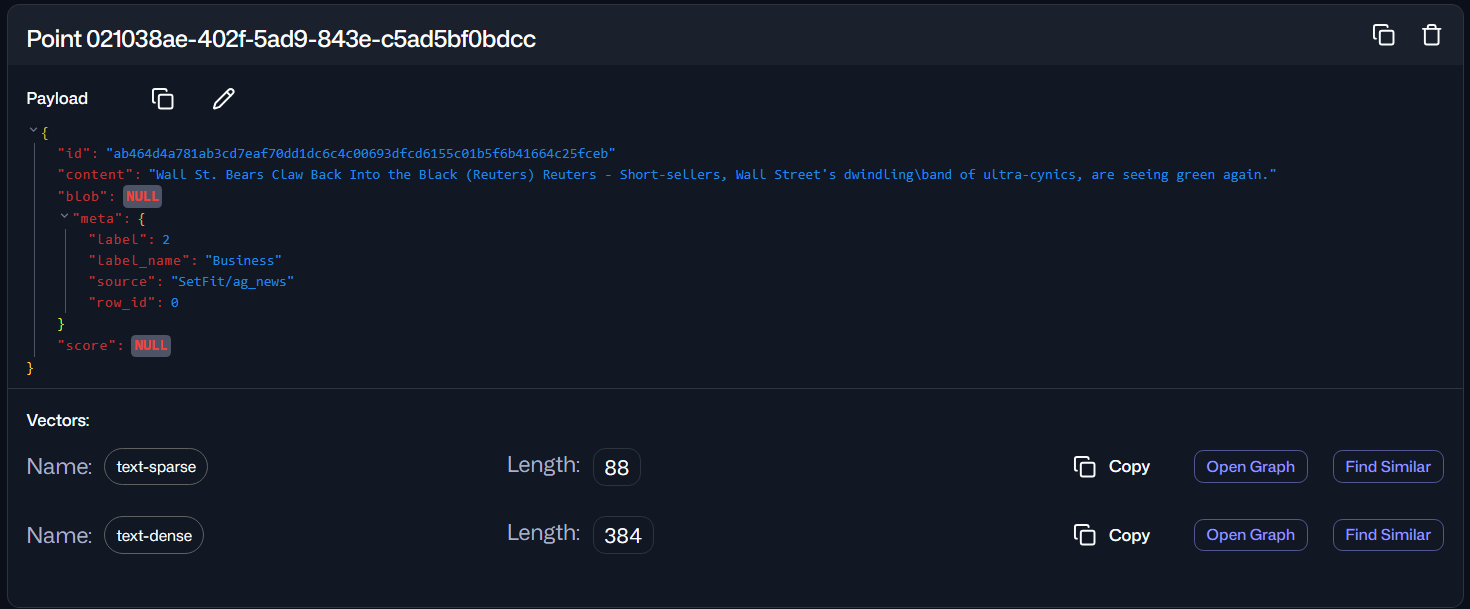

### Hybrid Score Notes

Hybrid scores are also ranking signals, not probabilities. `QdrantHybridRetriever` combines dense and sparse search results, so its scores come from fusion rather than plain dense-vector similarity. Treat them as useful for ordering results within the same hybrid query, not as confidence percentages and not as directly comparable with the dense-only scores above.